
**CUSTOMER CHURN PREDICTION MODEL**


Install dependencies

In [1]:
!pip install imbalanced-learn xgboost -q

ERROR: Could not install packages due to an OSError: [Errno 28] No space left on device


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, f1_score,
                              accuracy_score, precision_score, recall_score,
                              precision_recall_curve)
from imblearn.over_sampling import SMOTE
import xgboost as xgb

ModuleNotFoundError: No module named 'pandas'

Load dataset

In [ ]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
print("Shape:", df.shape)
print(df['Churn'].value_counts())

Shape: (7043, 21)
Churn
No     5174
Yes    1869
Name: count, dtype: int64


Preprocessing

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
df.drop('customerID', axis=1, inplace=True)
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

cat_cols = df.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

X = df.drop('Churn', axis=1)
y = df['Churn']


Train/Test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler() #StandardScaler normalises all 19 numeric features to zero mean and unit variance using the formula z = (x, μ) / σ
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

SMOTE (fix class imbalance)



 (Synthetic Minority Oversampling Technique)

In [ ]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)
print("After SMOTE:", pd.Series(y_train_sm).value_counts().to_dict())

After SMOTE: {0: 4139, 1: 4139}


Train models

Accuracy — % of all predictions correct. Misleading when classes are imbalanced.

Precision — Of all predicted churners, what % actually churned? High precision = fewer false alarms.

Recall — Of all actual churners, what % did we catch? High recall = fewer missed churners.

F1-score — Harmonic mean of precision and recall. Balances both — the primary metric here.

ROC-AUC — Area under the ROC curve. Measures discriminative power across all thresholds (0 = worst, 1 = perfect, 0.5 = random).

In [ ]:
#'balanced'=> computes weights as n_samples / (n_classes × class_count)

models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42),

    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42),

    'XGBoost':xgb.XGBClassifier(
        scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
        eval_metric='logloss',
        random_state=42),
}

results = {}

for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    proba = model.predict_proba(X_test_sc)[:, 1]

    # Threshold tuning: find best F1
    best_t, best_f1 = 0.5, 0
    for t in np.arange(0.3, 0.7, 0.01):
        preds = (proba >= t).astype(int)
        f = f1_score(y_test, preds)
        if f > best_f1:
            best_f1, best_t = f, t

    pred_opt = (proba >= best_t).astype(int)

    results[name] = {
        'model':     model,
        'proba':     proba,
        'threshold': best_t,
        'Accuracy':  accuracy_score(y_test, pred_opt),
        'Precision': precision_score(y_test, pred_opt),
        'Recall':    recall_score(y_test, pred_opt),
        'F1':        f1_score(y_test, pred_opt),
        'ROC-AUC':   roc_auc_score(y_test, proba),
    }
    print(f"\n{name} (threshold={best_t:.2f})")
    print(classification_report(y_test, pred_opt, target_names=['No Churn','Churn']))


Logistic Regression (threshold=0.64)
              precision    recall  f1-score   support

    No Churn       0.87      0.83      0.85      1035
       Churn       0.58      0.67      0.62       374

    accuracy                           0.78      1409
   macro avg       0.73      0.75      0.74      1409
weighted avg       0.80      0.78      0.79      1409


Random Forest (threshold=0.37)
              precision    recall  f1-score   support

    No Churn       0.89      0.77      0.82      1035
       Churn       0.53      0.72      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409


XGBoost (threshold=0.37)
              precision    recall  f1-score   support

    No Churn       0.90      0.71      0.80      1035
       Churn       0.50      0.79      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.7

Metrics summary table

In [ ]:
metrics_df = pd.DataFrame({
    name: {k: v for k, v in scores.items()
           if k not in ['model','proba','threshold']}
    for name, scores in results.items()
}).T.round(4)
print("\nMetrics Summary:")
print(metrics_df)


Metrics Summary:
                     Accuracy  Precision  Recall      F1  ROC-AUC
Logistic Regression    0.7842     0.5814  0.6684  0.6219   0.8389
Random Forest          0.7587     0.5335  0.7246  0.6145   0.8218
XGBoost                0.7317     0.4966  0.7861  0.6087   0.8146


ROC Curves (Receiver Operating Characteristic)

acceptable for a telecom churn problem with limited feature engineering. The advantage of AUC over accuracy is that it is threshold-independent — it measures the model's overall discriminative ability.

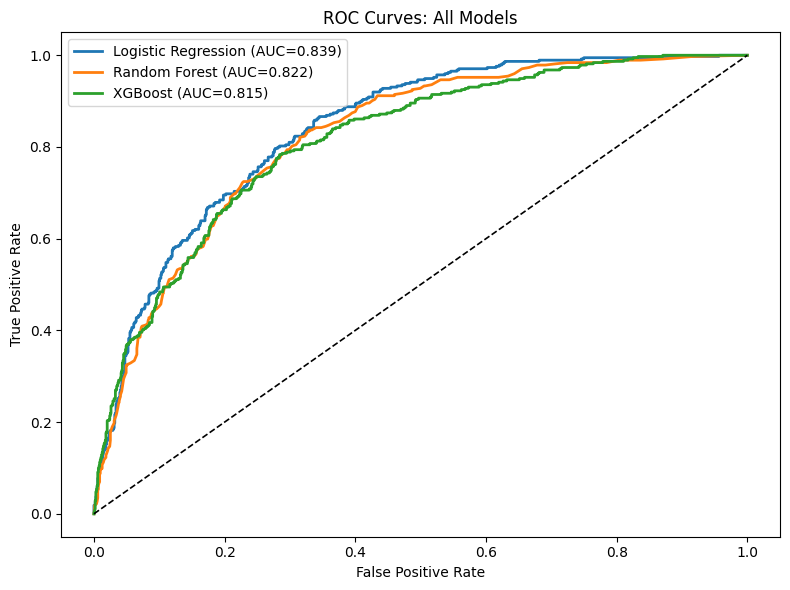

In [ ]:
#roc-auc value: meaning it correctly ranks a churner above a non churner 75% of the time when presented with a random pair

plt.figure(figsize=(8, 6))
for name, scores in results.items():
    fpr, tpr, _ = roc_curve(y_test, scores['proba'])
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={scores['ROC-AUC']:.3f})")
plt.plot([0,1],[0,1],'k--', lw=1.2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: All Models')
plt.legend()
plt.tight_layout()
plt.show()


Confusion Matrices (TN, FP, FN, TP)

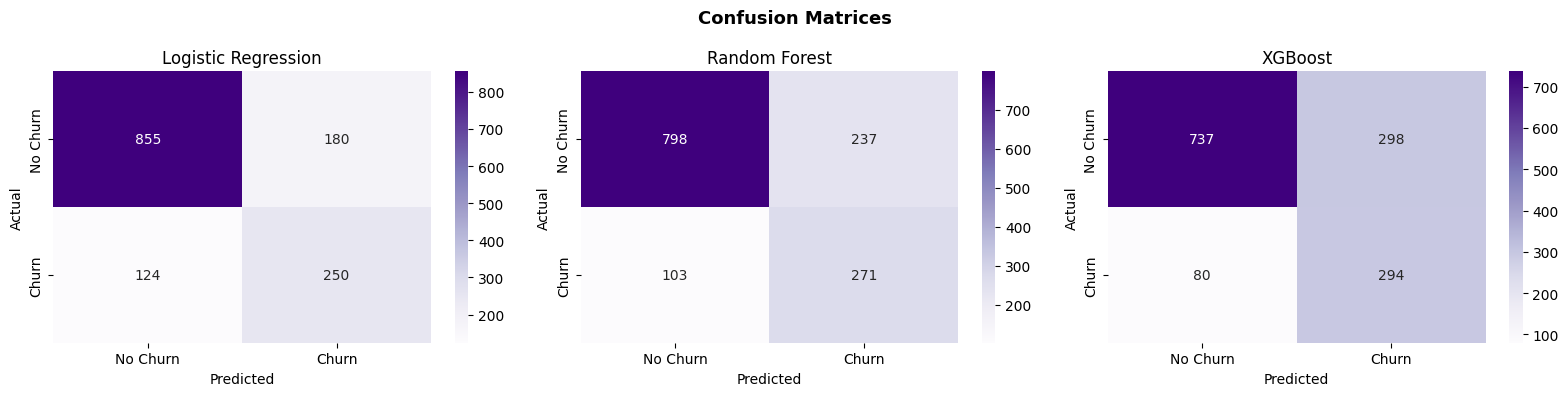

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, scores) in zip(axes, results.items()):
    pred = (scores['proba'] >= scores['threshold']).astype(int)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Purples',
                xticklabels=['No Churn','Churn'],
                yticklabels=['No Churn','Churn'])
    ax.set_title(f'{name}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Feature Importance (Random Forest)

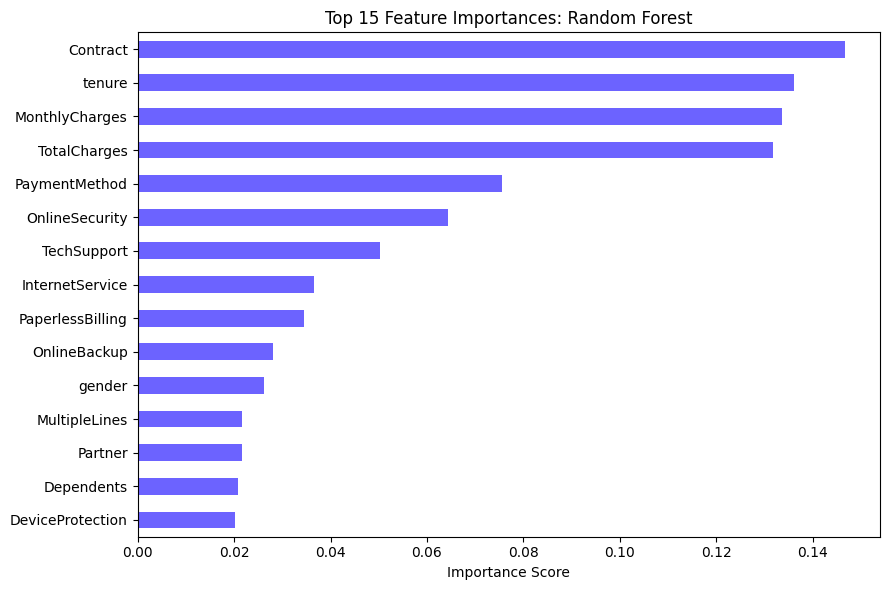

In [ ]:
rf = results['Random Forest']['model']
feat_imp = pd.Series(rf.feature_importances_,
                      index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
feat_imp.head(15).plot(kind='barh', color='#6C63FF')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances: Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

Churn probability distribution

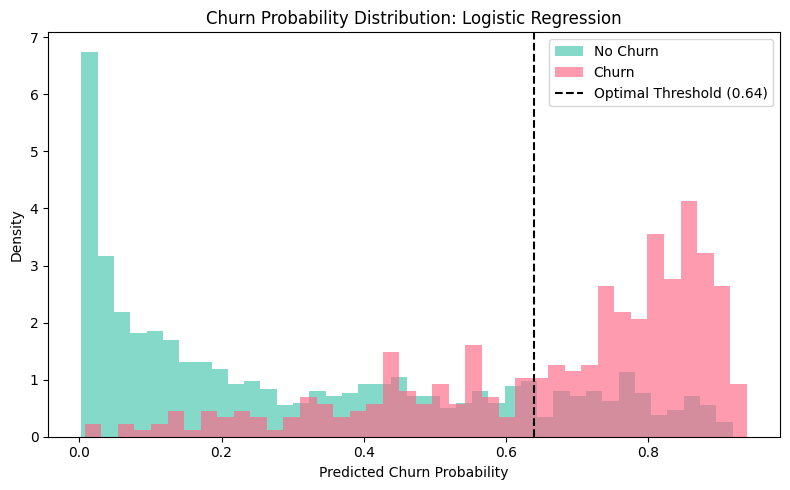

In [ ]:
best_name = max(results, key=lambda k: results[k]['ROC-AUC'])
proba_best = results[best_name]['proba']
thr = results[best_name]['threshold']

plt.figure(figsize=(8, 5))
plt.hist(proba_best[y_test==0], bins=40, alpha=0.65,
         color='#43C6AC', label='No Churn', density=True)
plt.hist(proba_best[y_test==1], bins=40, alpha=0.65,
         color='#FF6584', label='Churn', density=True)
plt.axvline(thr, color='black', linestyle='--',
            label=f'Optimal Threshold ({thr:.2f})')
plt.title(f'Churn Probability Distribution: {best_name}')
plt.xlabel('Predicted Churn Probability')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()